# import

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Data Load & Check Data

In [2]:

train = pd.read_csv(r"..\datasets\train.csv")
test = pd.read_csv(r"..\datasets\test.csv")
submission = pd.read_csv(r"..\datasets\sample_submission.csv")

train.head()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               748 non-null    object 
 1   generation                       748 non-null    int64  
 2   school1                          748 non-null    int64  
 3   major type                       726 non-null    object 
 4   major1_1                         728 non-null    object 
 5   major1_2                         309 non-null    object 
 6   major_data                       748 non-null    bool   
 7   job                              748 non-null    object 
 8   class1                           748 non-null    int64  
 9   class2                           169 non-null    float64
 10  class3                           14 non-null     float64
 11  class4                           1 non-null      float64
 12  re_registration       

# EDA & 데이터 전처리

## contest_award
삭제

In [3]:
print(train['contest_award'].unique())
train = train.drop(['contest_award'], axis=1)
test = test.drop(['contest_award'], axis=1)

[nan]


## ID
삭제

In [4]:
train = train.drop(['ID'], axis=1)
test = test.drop(['ID'], axis=1)

## generation
train 데이터에는 9기만 있고, test 데이터에는 10기만 있음 -> 삭제

In [5]:
print(train['generation'].value_counts(dropna=False))
print(test['generation'].value_counts(dropna=False))

generation
9    748
Name: count, dtype: int64
generation
10    814
Name: count, dtype: int64


In [6]:
train = train.drop(['generation'], axis=1)
test = test.drop(['generation'], axis=1)

## school1

In [7]:
print(f"고유값 개수: {train['school1'].nunique()}개")

고유값 개수: 92개


In [8]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

target_cols_to_enc = ['school1']
def safe_target_encoding(train_df, test_df, target_col, categorical_cols, n_splits=5):
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    
    # 1. Stratified K-Fold 설정 (타겟 분포 유지)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # 전체 평균 (Global Mean) - Train에 없는 카테고리가 Test에 나올 경우 대비
    global_mean = train_df[target_col].mean()
    
    for col in categorical_cols:
        # 새로운 컬럼명 생성
        new_col_name = f"{col}_target_enc"
        train_encoded[new_col_name] = np.nan
        
        # 2. Train 데이터 인코딩: Out-of-Fold 방식
        for train_idx, val_idx in skf.split(train_df, train_df[target_col]):
            # 학습 폴드와 검증 폴드 분리
            fold_train = train_df.iloc[train_idx]
            fold_val = train_df.iloc[val_idx]
            
            # 학습 폴드에서의 카테고리별 타겟 평균 계산
            target_mean = fold_train.groupby(col)[target_col].mean()
            
            # 검증 폴드에 매핑 (없는 값은 전체 평균으로 채움)
            train_encoded.loc[val_idx, new_col_name] = train_encoded.loc[val_idx, col].map(target_mean)
            
        # 3. Test 데이터 인코딩: Train 전체의 타겟 평균 사용
        overall_target_mean = train_df.groupby(col)[target_col].mean()
        test_encoded[new_col_name] = test_encoded[col].map(overall_target_mean).fillna(global_mean)
        
        # 결측치 처리 (Train 내에서 특정 폴드에만 등장하는 카테고리 등)
        train_encoded[new_col_name] = train_encoded[new_col_name].fillna(global_mean)
        
        # 기존 원본 범주형 컬럼 삭제
        train_encoded = train_encoded.drop(columns=[col])
        test_encoded = test_encoded.drop(columns=[col])
        
    return train_encoded, test_encoded

train, test =  safe_target_encoding(train, test, 'completed', target_cols_to_enc)

## class1~4 다 살리는 경우

In [9]:
def encode_class_dummies(train_df, test_df):
    class_cols = ['class1', 'class2', 'class3', 'class4']
    
    for col in class_cols:
        if col in train_df.columns:
            # 1. 결측치 처리 및 정수 변환
            train_df[col] = train_df[col].fillna(-1).astype(int)
            test_df[col] = test_df[col].fillna(-1).astype(int)
            
            # 2. 원-핫 인코딩 수행
            train_dummies = pd.get_dummies(train_df[col], prefix=col)
            test_dummies = pd.get_dummies(test_df[col], prefix=col)
            
            # 3. [중요] Train과 Test의 컬럼 구성 맞추기
            # Train에는 있는데 Test에는 없는 컬럼은 Test에 0으로 추가
            # Test에는 있는데 Train에는 없는 컬럼은 삭제 (학습 기준)
            test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)
            
            # 4. 기존 데이터와 합치기
            train_df = pd.concat([train_df, train_dummies], axis=1)
            test_df = pd.concat([test_df, test_dummies], axis=1)
            
            # 5. 원본 컬럼 삭제
            train_df = train_df.drop(columns=[col])
            test_df = test_df.drop(columns=[col])
            
    return train_df, test_df

# --- 실제 적용 ---
train, test = encode_class_dummies(train, test)

## nationality
결측치 1개를 최빈값인 내국인으로 채움

In [10]:
# 각 고유값의 빈도수 확인
print(train['nationality'].value_counts(dropna=False))
print(test['nationality'].value_counts(dropna=False)) 
train['nationality'] = train['nationality'].fillna(train['nationality'].mode()[0])
print(train['nationality'].value_counts(dropna=False))

nationality
내국인    745
외국인      2
NaN      1
Name: count, dtype: int64
nationality
내국인    810
외국인      4
Name: count, dtype: int64
nationality
내국인    746
외국인      2
Name: count, dtype: int64


## major type / major1_1 / major1_2
- major1_1과 major1_2를 보고 major type을 단일 전공, 복수 전공, 미입력으로 나눔
- major1_1과 major1_2의 nan값은 미입력으로 변환함

In [11]:
print(train['major type'].value_counts(dropna=False))
print(test['major type'].value_counts(dropna=False)) 

major type
단일 전공                      410
복수 전공 ( 다중전공, 이중전공 포함 )    315
NaN                         22
단일 전공공학 (컴퓨터 공학 제외)          1
Name: count, dtype: int64
major type
단일 전공                      446
복수 전공 ( 다중전공, 이중전공 포함 )    294
NaN                         74
Name: count, dtype: int64


In [12]:
# 1. major_type이 '단일 전공공학 (컴퓨터 공학 제외)'인 행 필터링
specific_major = train[train['major type'] == '단일 전공공학 (컴퓨터 공학 제외)']

# 2. 해당 데이터의 major1_1과 major1_2 값만 출력
print(specific_major[['major1_1', 'major1_2']])

          major1_1 major1_2
290  IT(컴퓨터 공학 포함)      NaN


In [13]:
both_nan_count = train[train['major1_1'].isna() & train['major1_2'].isna()].shape[0]
print(f"제1전공과 제2전공이 모두 없는 데이터 개수: {both_nan_count}개")

both_nan_count = test[test['major1_1'].isna() & test['major1_2'].isna()].shape[0]
print(f"제1전공과 제2전공이 모두 없는 데이터 개수: {both_nan_count}개")

제1전공과 제2전공이 모두 없는 데이터 개수: 20개
제1전공과 제2전공이 모두 없는 데이터 개수: 73개


In [14]:
# 1. 제1전공과 제2전공 모두 값이 있는데 (notna), 
#    major_type이 '단일 전공'이거나 결측치(nan)인 경우 -> '복수전공 ( 다중전공, 이중전공 포함 )'으로 변경
cond1 = (train['major1_1'].notna()) & (train['major1_2'].notna()) & \
        ((train['major type'] == '단일 전공') | (train['major type'].isna()))
train.loc[cond1, 'major type'] = '복수 전공 ( 다중전공, 이중전공 포함 )'

cond1 = (test['major1_1'].notna()) & (test['major1_2'].notna()) & \
        ((test['major type'] == '단일 전공') | (test['major type'].isna()))
test.loc[cond1, 'major type'] = '복수 전공 ( 다중전공, 이중전공 포함 )'


# 2. 제1전공이나 제2전공 중 하나만 값이 있는데 (한쪽이 nan), 
#    major_type이 '복수전공 ( 다중전공, 이중전공 포함 )'이거나 결측치(nan)인 경우 -> '단일 전공'으로 변경
#    (보통 major1_1은 필수이므로 major1_2가 nan인 경우를 체크합니다)
cond2 = (train['major1_1'].notna()) & (train['major1_2'].isna()) & \
        ((train['major type'] == '복수 전공 ( 다중전공, 이중전공 포함 )') | (train['major type'].isna()))
train.loc[cond2, 'major type'] = '단일 전공'

cond2 = (test['major1_1'].notna()) & (test['major1_2'].isna()) & \
        ((test['major type'] == '복수 전공 ( 다중전공, 이중전공 포함 )') | (test['major type'].isna()))
test.loc[cond2, 'major type'] = '단일 전공'

# 결과 확인
print(train['major type'].value_counts(dropna=False))
print(test['major type'].value_counts(dropna=False))

major type
단일 전공                      418
복수 전공 ( 다중전공, 이중전공 포함 )    309
NaN                         20
단일 전공공학 (컴퓨터 공학 제외)          1
Name: count, dtype: int64
major type
복수 전공 ( 다중전공, 이중전공 포함 )    631
단일 전공                      110
NaN                         73
Name: count, dtype: int64


In [15]:
train['major type'] = train['major type'].replace('단일 전공공학 (컴퓨터 공학 제외)', '단일 전공')

# 변경 결과 확인
print(train['major type'].value_counts(dropna=False))

major type
단일 전공                      419
복수 전공 ( 다중전공, 이중전공 포함 )    309
NaN                         20
Name: count, dtype: int64


In [16]:
print(train['major1_1'].value_counts(dropna=False))
print(test['major1_1'].value_counts(dropna=False))

major1_1
IT(컴퓨터 공학 포함)    253
경영학              178
자연과학              97
사회과학              57
인문학               48
경제통상학             36
의약학               29
NaN               20
예체능               15
교육학               10
법학                 3
기타                 2
Name: count, dtype: int64
major1_1
NaN            73
경영학과           47
통계학과           46
응용통계학과         30
경영학부           26
               ..
시스템생명공학과        1
에너지시스템공학부       1
ICT융합학부         1
영어학과            1
ai소프트웨어융합학부     1
Name: count, Length: 289, dtype: int64


In [17]:
# '미입력'으로 채우기 전에 수행
train['is_major1_1_nan'] = train['major1_1'].isna().astype(int)
test['is_major1_1_nan'] = test['major1_1'].isna().astype(int)

In [18]:
print(train['major1_2'].value_counts(dropna=False))
print(test['major1_2'].value_counts(dropna=False))

major1_2
NaN              439
IT(컴퓨터 공학 포함)    139
경영학               66
자연과학              53
사회과학              19
경제통상학             18
기타                 4
예체능                4
의약학                3
인문학                2
교육학                1
Name: count, dtype: int64
major1_2
없음                     336
NaN                    183
통계학과                    23
경영학과                    19
컴퓨터공학과                  16
                      ... 
소비자생활문화산업학과              1
빅데이터 융합학과                1
AI융합학부 AI학과              1
융합소프트웨어학부 데이터사이언스학과      1
데이터사이언스 소프트웨어학과          1
Name: count, Length: 154, dtype: int64


In [19]:
# '미입력'으로 채우기 전에 수행
train['is_major1_2_nan'] = train['major1_2'].isna().astype(int)
test['is_major1_2_nan'] = test['major1_2'].isna().astype(int)

In [20]:
# major_type의 NaN을 '미입력'으로 채우기
train['major type'] = train['major type'].fillna('미입력')
test['major type'] = test['major type'].fillna('미입력')
cols = ['major1_1', 'major1_2']
train[cols] = train[cols].fillna('미입력')
test[cols] = test[cols].fillna('미입력')

print(train['major type'].value_counts(dropna=False))
print(test['major type'].value_counts(dropna=False))

major type
단일 전공                      419
복수 전공 ( 다중전공, 이중전공 포함 )    309
미입력                         20
Name: count, dtype: int64
major type
복수 전공 ( 다중전공, 이중전공 포함 )    631
단일 전공                      110
미입력                         73
Name: count, dtype: int64


## major_data

In [21]:
print(train['major_data'].value_counts(dropna=False))
print(test['major_data'].value_counts(dropna=False))

major_data
False    421
True     327
Name: count, dtype: int64
major_data
False    487
True     327
Name: count, dtype: int64


## job

In [22]:
print(train['job'].value_counts(dropna=False))
print(test['job'].value_counts(dropna=False))

job
대학생     662
취준생      48
직장인      29
대학원생      9
Name: count, dtype: int64
job
대학생     690
취준생      76
직장인      34
대학원생     14
Name: count, dtype: int64


## re_registration

In [23]:
print(train['re_registration'].value_counts(dropna=False))
print(test['re_registration'].value_counts(dropna=False))

re_registration
아니요    602
예      146
Name: count, dtype: int64
re_registration
아니요    659
예      155
Name: count, dtype: int64


## inflow_route
너무 적은 값들은 '기타'에 넣음

In [24]:
print(train['inflow_route'].value_counts(dropna=False))
print(test['inflow_route'].value_counts(dropna=False))

inflow_route
에브리타임                               340
기존 학회원 또는 운영진                       150
인스타그램                               121
지인 추천                                78
대외활동 사이트(링커리어, 캠퍼스픽, 캠퍼즈, 위비티 등)     55
기타                                    2
교내 플랫폼 (에브리타임 X)                      1
인터넷 검색                                1
Name: count, dtype: int64
inflow_route
에브리타임                               419
인스타그램                               156
기존 BDA 오픈채팅방                         89
지인 추천                                77
대외활동 사이트(링커리어, 캠퍼스픽, 캠퍼즈, 위비티 등)     62
직장인 커뮤니티(블라인드, 링크드인 등)                5
B.D.A 행사 (잡페스티벌, WAVE)                2
기존 BDA 학회원                            1
인터넷 검색                                1
bda 9기활동                              1
네이버 블로그                               1
Name: count, dtype: int64


In [25]:
# 1. 유지할 항목 리스트 (기존 BDA 오픈채팅방 추가)
top_routes = ['에브리타임', '기존 학회원 또는 운영진', '인스타그램', '지인 추천', '대외활동 사이트(링커리어, 캠퍼스픽, 캠퍼즈, 위비티 등)','기존 BDA 오픈채팅방']

# 2. 지정한 항목 외에는 모두 '기타'로 통합
train['inflow_route'] = train['inflow_route'].apply(lambda x: x if x in top_routes else '기타')
test['inflow_route'] = test['inflow_route'].apply(lambda x: x if x in top_routes else '기타')

# 3. 결과 확인
print("--- Train 데이터 결과 ---")
print(train['inflow_route'].value_counts())
print("\n--- Test 데이터 결과 ---")
print(test['inflow_route'].value_counts())

--- Train 데이터 결과 ---
inflow_route
에브리타임                               340
기존 학회원 또는 운영진                       150
인스타그램                               121
지인 추천                                78
대외활동 사이트(링커리어, 캠퍼스픽, 캠퍼즈, 위비티 등)     55
기타                                    4
Name: count, dtype: int64

--- Test 데이터 결과 ---
inflow_route
에브리타임                               419
인스타그램                               156
기존 BDA 오픈채팅방                         89
지인 추천                                77
대외활동 사이트(링커리어, 캠퍼스픽, 캠퍼즈, 위비티 등)     62
기타                                   11
Name: count, dtype: int64


## whyBDA
너무 적은 값들은 기타에 넣음

In [26]:
print(train['whyBDA'].value_counts(dropna=False))
print(test['whyBDA'].value_counts(dropna=False))

whyBDA
혼자 공부하기 어려워서                                         271
큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서                   159
이전 기수에 매우 만족해서                                       146
BDA 학회원만의 혜택을 누리고 싶어서(현직자 강연, 잡 페스티벌, 기업연계 공모전 등)     64
현직자의 강의를 듣고 싶어서                                       56
시간적으로 부담이 없어서                                         29
학회 가입 시 코딩 테스트, 면접 등을 보지 않아서                          23
Name: count, dtype: int64
whyBDA
혼자 공부하기 어려워서                                         377
큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서                   164
BDA 학회원만의 혜택을 누리고 싶어서(현직자 강연, 잡 페스티벌, 기업연계 공모전 등)     82
현직자의 강의를 듣고 싶어서                                       75
시간적으로 부담이 없어서                                         67
학회 가입 시 코딩 테스트, 면접 등을 보지 않아서                          46
현직자 강연 등 BDA 학회원의 혜택과 큰 규모인 만큼 관리가 잘 될 것 같다는 기대        1
강연, 기업연계 및 공모전 참여로 능력 향상                               1
학교에 빅데이터 학회가 없어서                                       1
Name: count, dtype: int64


In [27]:
# 1. 유지할 주요 응답 리스트 (빈도수가 높은 항목들)
top_reasons = [
    '혼자 공부하기 어려워서',
    '큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서',
    '이전 기수에 매우 만족해서',
    'BDA 학회원만의 혜택을 누리고 싶어서(현직자 강연, 잡 페스티벌, 기업연계 공모전 등)',
    '현직자의 강의를 듣고 싶어서',
    '시간적으로 부담이 없어서',
    '학회 가입 시 코딩 테스트, 면접 등을 보지 않아서'
]

# 2. 리스트에 없는 항목들은 모두 '기타'로 변경 (Train/Test 동일 적용)
train['whyBDA'] = train['whyBDA'].apply(lambda x: x if x in top_reasons else '기타')
test['whyBDA'] = test['whyBDA'].apply(lambda x: x if x in top_reasons else '기타')

# 3. 결과 확인
print(train['whyBDA'].value_counts())
print(test['whyBDA'].value_counts())

whyBDA
혼자 공부하기 어려워서                                         271
큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서                   159
이전 기수에 매우 만족해서                                       146
BDA 학회원만의 혜택을 누리고 싶어서(현직자 강연, 잡 페스티벌, 기업연계 공모전 등)     64
현직자의 강의를 듣고 싶어서                                       56
시간적으로 부담이 없어서                                         29
학회 가입 시 코딩 테스트, 면접 등을 보지 않아서                          23
Name: count, dtype: int64
whyBDA
혼자 공부하기 어려워서                                         377
큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서                   164
BDA 학회원만의 혜택을 누리고 싶어서(현직자 강연, 잡 페스티벌, 기업연계 공모전 등)     82
현직자의 강의를 듣고 싶어서                                       75
시간적으로 부담이 없어서                                         67
학회 가입 시 코딩 테스트, 면접 등을 보지 않아서                          46
기타                                                     3
Name: count, dtype: int64


## what_to_gain
너무 적은 값들은 기타에 넣음

In [28]:
print(train['what_to_gain'].value_counts(dropna=False))
print(test['what_to_gain'].value_counts(dropna=False))

what_to_gain
데이터 분석 역량                                                                          492
프로젝트 경험                                                                            149
공모전 경험                                                                              73
인적 네트워크                                                                             29
기초적인 python, sql 지식 숙지                                                               1
위 항목 전체                                                                              1
공모전과 프로젝트                                                                            1
사실 한가지를 고르기 어렵습니다..ㅠㅠ 학회를 통해 위의 4가지와 협업에 계신 전문가님들에게 유익한 정보를 얻고 소중한 경험을 하고 싶습니다.      1
분석 역량, 공모전 경험, 인적 네트워크                                                               1
Name: count, dtype: int64
what_to_gain
데이터 분석 역량                                                                        502
프로젝트 경험                                                                         

In [29]:
top_gain = ['데이터 분석 역량', '프로젝트 경험', '공모전 경험', '인적 네트워크']

train['what_to_gain'] = train['what_to_gain'].apply(lambda x: x if x in top_gain else '기타')
test['what_to_gain'] = test['what_to_gain'].apply(lambda x: x if x in top_gain else '기타')

# 3. 결과 확인
print(train['what_to_gain'].value_counts())
print(test['what_to_gain'].value_counts())

what_to_gain
데이터 분석 역량    492
프로젝트 경험      149
공모전 경험        73
인적 네트워크       29
기타             5
Name: count, dtype: int64
what_to_gain
데이터 분석 역량    502
프로젝트 경험      198
공모전 경험        79
인적 네트워크       32
기타             3
Name: count, dtype: int64


## hope_for_group

In [30]:
print(train['hope_for_group'].value_counts(dropna=False))
print(test['hope_for_group'].value_counts(dropna=False))

hope_for_group
네. 오프라인으로 참여하고 싶어요          367
네. 온라인으로 참여하고 싶어요           265
아니요. 개인적으로 학회 활동을 하고 싶어요    116
Name: count, dtype: int64
hope_for_group
네. 오프라인으로 참여하고 싶어요          429
네. 온라인으로 참여하고 싶어요           274
아니요. 개인적으로 학회 활동을 하고 싶어요    111
Name: count, dtype: int64


## 기존 previous_class_3~9 삭제 / previous_class_3_0001 ~ 0009 ... previous_class_9_0001 ~ 0009 (new!)

In [31]:
def process_previous_classes(df):
    # 처리할 대상 컬럼 리스트 생성 (3번부터 9번까지)
    previous_class_cols = [f'previous_class_{i}' for i in range(3, 10)]
    
    class_types = {
        '0001 : 파이썬 문법 기초반': '0001',
        '0002 : SQL 문법 기초반': '0002',
        '0003 : R문법 기초반': '0003',
        '0004 : 데이터 분석 입문반 (머신러닝)': '0004',
        '0005 : 데이터 분석 입문반 (통계)': '0005',
        '0006 : 데이터 분석 전처리반(판다스)': '0006',
        '0007 : 데이터 분석 전처리 적용반': '0007',
        '0008 : 데이터 분석 모델링반 (ML1)': '0008',
        '0009 : 데이터 분석 개념반': '0009'
    }
    
    for col in previous_class_cols:
        if col in df.columns:
            # 각 강의 코드별로 새로운 컬럼 생성
            for class_name, class_code in class_types.items():
                df[f'{col}_{class_code}'] = df[col].apply(
                    lambda x: 1 if isinstance(x, str) and class_name in x else 0
                )
            # 처리가 완료된 원본 텍스트 컬럼 삭제
            df = df.drop(columns=[col])
            
    # 모든 반복문이 끝난 뒤에 최종 데이터프레임을 반환합니다.
    return df

# --- 실제 적용 ---
train = process_previous_classes(train)
test = process_previous_classes(test)

## major_field / is_major_it (new!)
- major_field의 nan값은 '미입력'으로 채움
- major_field에 IT가 포함되어 있으면 is_major_it가 1, 아니면 0

In [32]:
print(train['major_field'].value_counts(dropna=False))
print(test['major_field'].value_counts(dropna=False))

major_field
IT (컴퓨터 공학 포함)                               138
공학 (컴퓨터 공학 제외)                               125
경영학                                           99
자연과학                                          84
사회과학                                          75
인문학                                           43
NaN                                           23
경제통상학                                         19
IT (컴퓨터 공학 포함), 공학 (컴퓨터 공학 제외)                13
예체능                                           11
IT (컴퓨터 공학 포함), 자연과학                          10
경영학, 인문학                                      10
의약학                                            9
IT (컴퓨터 공학 포함), 경영학                            8
경영학, 사회과학                                      8
교육학                                            7
자연과학, 경영학                                      7
경제통상학, 사회과학                                    6
공학 (컴퓨터 공학 제외), 자연과학                           5
IT (컴퓨터 공학 포함), 인문학                            5
IT (컴퓨터 

In [33]:
# 결측치를 먼저 '미입력'으로 채움
train['major_field'] = train['major_field'].fillna('미입력')
test['major_field'] = test['major_field'].fillna('미입력')

# major_field(전공분야) 칼럼에 IT가 포함되어 있으면 is_major_it가 1, 아니면 0
train['is_major_it'] = train['major_field'].str.contains('IT', regex=True).astype(int)
test['is_major_it'] = test['major_field'].str.contains('IT', regex=True).astype(int)

In [34]:
train = train.drop(['major_field'], axis=1)
test = test.drop(['major_field'], axis=1)

## desired_career_path

In [35]:
print(train['desired_career_path'].value_counts(dropna=False))
print(test['desired_career_path'].value_counts(dropna=False))

desired_career_path
취업        573
대학원 진학    143
이직         24
창업          8
Name: count, dtype: int64
desired_career_path
취업          601
대학원 진학      169
이직           26
창업            9
현재 직장 유지      9
Name: count, dtype: int64


## completed_semester / is_senior (new!) / is_unknown_semester (new!)
- completed_semester의 이상치 2개는 중앙값으로 대체하고, nan값은 -1으로 대체함
- is_senior는 6학기 이상이면 1, 아니면 0
- is_unknown_semester는 정보를 안썼으면 1, 아니면 0

In [36]:
print(train['completed_semester'].value_counts(dropna=False))
print(test['completed_semester'].value_counts(dropna=False))

completed_semester
6.00        205
8.00        193
4.00        134
7.00         74
5.00         40
2.00         29
NaN          28
9.00         20
3.00         10
10.00         9
20241.00      2
1.00          2
2020.02       1
0.00          1
Name: count, dtype: int64
completed_semester
5.0     170
7.0     168
8.0     154
6.0      90
NaN      74
3.0      63
4.0      41
9.0      30
2.0      11
10.0      9
1.0       4
Name: count, dtype: int64


In [37]:
def preprocess_semester_fixed(df):
    # 1. 이상치(10학기 초과)를 NaN으로 임시 변경하여 중앙값 계산에서 제외
    df.loc[df['completed_semester'] > 10, 'completed_semester'] = np.nan
    
    # 2. 중앙값 계산 (이상치와 원래 NaN이 모두 제외된 순수 데이터의 중앙값)
    semester_median = df['completed_semester'].median()
    
    # 3. 이상치였던 자리(NaN)를 중앙값으로 채우기
    # ※ 주의: 원래부터 NaN이었던 값과 이상치였던 값을 구분하기 위해 순서가 중요합니다.
    # 여기서는 '이상치만' 선택해서 중앙값으로 먼저 바꿉니다.
    df.loc[df['completed_semester'] > 10, 'completed_semester'] = semester_median
    
    # 4. 남아있는 모든 결측치(원래 NaN + 처리가 덜 된 이상치 등)를 -1로 채우기
    df['completed_semester'] = df['completed_semester'].fillna(-1)
    
    # 5. 정수형으로 변환
    df['completed_semester'] = df['completed_semester'].astype(int)
    
    return df

# 적용
train = preprocess_semester_fixed(train)
test = preprocess_semester_fixed(test)

# 결과 확인
print(train['completed_semester'].value_counts().sort_index())

completed_semester
-1      31
 0       1
 1       2
 2      29
 3      10
 4     134
 5      40
 6     205
 7      74
 8     193
 9      20
 10      9
Name: count, dtype: int64


C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\3829943220.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=semester_pivot, x='completed_semester', y='completed', palette='viridis')


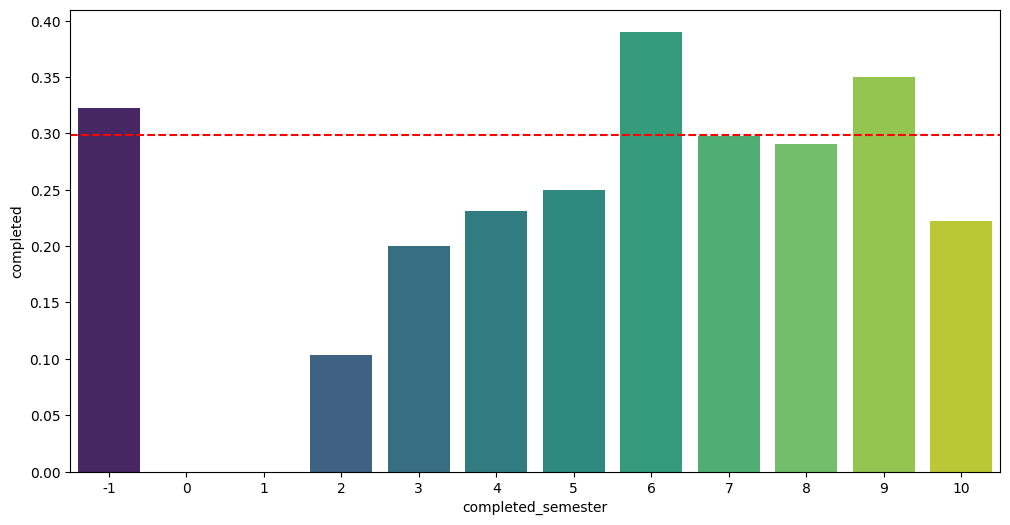

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 학기별 수료율 계산 (이상치 제거 후 실행 권장)
semester_pivot = train.groupby('completed_semester')['completed'].mean().reset_index()

# 2. 시각화 설정
plt.figure(figsize=(12, 6))
sns.barplot(data=semester_pivot, x='completed_semester', y='completed', palette='viridis')

# 3. 평균 수료율 선 표시 (전체 기준)
plt.axhline(train['completed'].mean(), color='red', linestyle='--', label='전체 평균 수료율')

plt.show()

In [39]:
# 1. 6학기 이상이면 1, 아니면 0 (여기서 -1은 자동으로 0이 됨)
train['is_senior'] = (train['completed_semester'] >= 6).astype(int)
test['is_senior'] = (test['completed_semester'] >= 6).astype(int)

# 2. 학기 미기입 여부를 알려주는 변수 추가
train['is_unknown_semester'] = (train['completed_semester'] == -1).astype(int)
test['is_unknown_semester'] = (test['completed_semester'] == -1).astype(int)

## project_type

In [40]:
print(train['project_type'].value_counts(dropna=False))
print(test['project_type'].value_counts(dropna=False))

project_type
팀     527
개인    221
Name: count, dtype: int64
project_type
팀     576
개인    238
Name: count, dtype: int64


## time_input
- 5.0보다 큰 값은 모두 5.0으로 변환

In [41]:
print(train['time_input'].value_counts(dropna=False))
print(test['time_input'].value_counts(dropna=False))

time_input
2.0     395
3.0     121
1.0     117
4.0      58
5.0      20
1.5      17
6.0       8
0.0       4
10.0      2
2.5       2
0.7       1
24.0      1
7.0       1
8.0       1
Name: count, dtype: int64
time_input
2.0     323
3.0     193
1.0     149
4.0      63
5.0      38
6.0      15
1.5      11
10.0      5
8.0       4
0.5       3
2.5       3
0.0       2
7.0       2
12.0      2
0.8       1
Name: count, dtype: int64


In [42]:
Q1 = train['time_input'].quantile(0.25)
Q3 = train['time_input'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

print(f"통계적 상한선: {upper_limit}")

통계적 상한선: 4.5


C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\900728092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_analysis, x='time_input', y='mean', ax=ax1, palette='Blues_d', alpha=0.7)
C:\Users\ghkda\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ghkda\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ghkda\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

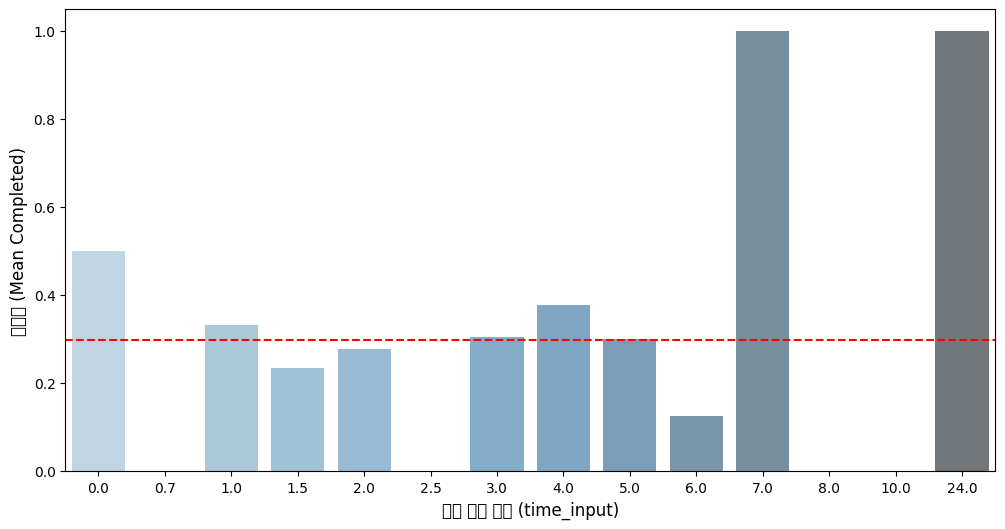

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시간대별 수료율과 응답자 수(count) 계산
time_analysis = train.groupby('time_input')['completed'].agg(['mean', 'count']).reset_index()

# 2. 시각화 설정
fig, ax1 = plt.subplots(figsize=(12, 6))

# 수료율 막대 그래프 (왼쪽 축)
sns.barplot(data=time_analysis, x='time_input', y='mean', ax=ax1, palette='Blues_d', alpha=0.7)
ax1.set_ylabel('수료율 (Mean Completed)', fontsize=12)
ax1.set_xlabel('주당 투자 시간 (time_input)', fontsize=12)
ax1.axhline(train['completed'].mean(), color='red', linestyle='--', label='전체 평균 수료율')
plt.show()

In [44]:
upper_limit = 5.0
train.loc[train['time_input'] > upper_limit, 'time_input'] = upper_limit
test.loc[test['time_input'] > upper_limit, 'time_input'] = upper_limit

## 기존 desired_job 삭제 / desired_job_A ... desired_job_기타(new!)
- 한 칸에 "A. 데이터 엔지니어, B. 데이터 분석가"라고 적혀 있던 것을 desired_job_A, desired_job_B 등 여러 개의 컬럼으로 만들고, 해당하면 1, 아니면 0으로 채움 (멀티 레이블 인코딩)
- 한 사람이 여러 직무를 희망할 경우, '이 사람은 A도 희망하고(1), B도 희망한다(1)"는 사실을 명확하게 알려줌
- 희소 답변 정리: 너무 특이하거나 드문 답변들은 '기타'로 묶어 모델이 복잡해지는 것을 방지하고 학습의 효율을 높임

In [45]:
def process_job_columns(df):
    # 컬럼이 존재할 때만 실행
    if 'desired_job' in df.columns:
        job_categories = {
            'A. 데이터 엔지니어': 'A',
            'B. 데이터 분석가': 'B',
            'C. 데이터 사이언티스트': 'C',
            'D. 인공지능 전문가': 'D',
            'E. 소프트웨어 개발자': 'E',
            'F. UI/UX 디자이너': 'F',
            'G. PM/서비스 기획자': 'G',
            'H. 자연과학계열 연구자': 'H',
            'I. 마케터': 'I',
            'J. MD': 'J'
        }
        
        # 1. 정해진 카테고리별로 컬럼 생성
        for job_name, job_code in job_categories.items():
            df[f'desired_job_{job_code}'] = df['desired_job'].apply(
                lambda x: 1 if isinstance(x, str) and job_name in x else 0
            )
            
        # 2. '기타' 카테고리 처리
        df['desired_job_기타'] = df['desired_job'].apply(
            lambda x: 1 if isinstance(x, str) and x.strip() != '' and 
            not any(cat in x for cat in job_categories.keys()) else 0
        )
        
        # 3. 원본 컬럼 삭제
        df = df.drop(columns=['desired_job'])
        
    return df

# --- 실제 적용 ---
train = process_job_columns(train)
test = process_job_columns(test)

## 기존 certificate_acquisition 삭제 / has_cert_now (new!)
'ADsP', ' SQL','구글 애널리스트has_cert_now','빅데이터 분석 기사','정보처리기사','태블로','사회조사분석사','AWS','SAS','사조사','정보처리산업기사','정보처리기능사','네트워크관리사','리눅스'라는 단어들 중 하나라도 대소문자와 띄어쓰기 구분 없이 필수적으로 들어있고, '준비중' 이 없으면 has_cert_now가 1, 아니면 0

In [46]:
print(train['certificate_acquisition'].value_counts(dropna=False))
print(test['certificate_acquisition'].value_counts(dropna=False))

certificate_acquisition
없음                                460
ADsP                              107
ADsP, SQLD                         66
SQLD                               48
구글 애널리스트                           11
ADsP, 빅데이터 분석 기사                    6
정보처리기사                              5
ADsP, SQLD, 정보처리기사                  5
ADsP, 정보처리기사                        4
기타                                  4
컴퓨터활용능력                             3
ADsP, 구글 애널리스트                      3
ADsP, SQLD, 구글 애널리스트                3
SQLD, 구글 애널리스트                      3
SQLD, 정보처리기사                        2
준비중: SQLD                           2
준비중                                 2
빅데이터 분석 기사                          2
준비중: ADsP, SQLD                     2
ADsP, SQLD, 빅데이터 분석 기사, 정보처리기사      2
ADsP, SQLD, 빅데이터 분석 기사              2
ADsP, 정보처리기사, 구글 애널리스트              1
태블로, 구글 애널리스트                       1
빅데이터 분석 기사, 정보처리기사                  1
ADsP, 정보처리기사, SQLD                  1
AWS                       

In [47]:
import re

def preprocess_cert_strict(df):
    # 1. 대상 자격증 리스트
    target_list = [
        'ADsP', 'SQL', '구글애널리스트', '빅데이터분석기사', '정보처리기사', 
        '태블로', '사회조사분석사', 'AWS', 'SAS', '사조사', 
        '정보처리산업기사', '정보처리기능사', '네트워크관리사','리눅스',
    ]
    
    # 2. 정규표현식 패턴 생성 (띄어쓰기 무시)
    pattern = '|'.join(['\s*'.join(list(cert)) for cert in target_list])

    def check_ownership(text):
        if pd.isna(text) or text == '없음':
            return 0
        
        # 텍스트를 문자열로 변환
        val = str(text)
        
        # 관련 키워드가 있는지 확인 (대소문자 무시)
        has_target = re.search(pattern, val, re.IGNORECASE)
        
        # 조건: 관련 키워드가 있고 '준비중'이라는 단어가 절대 없어야만 1
        if has_target and ('준비중' not in val):
            return 1
        else:
            # 키워드가 없거나, 있더라도 '준비중'이 포함되면 0
            return 0

    # 파생 변수 생성
    df['has_cert_now'] = df['certificate_acquisition'].apply(check_ownership)
    
    return df

# 데이터 적용
train = preprocess_cert_strict(train)
test = preprocess_cert_strict(test)

# 결과 확인: 엄격한 분류 기준에 따른 수료율 차이 확인
print(train.groupby('has_cert_now')['completed'].mean())

has_cert_now
0    0.251586
1    0.378182
Name: completed, dtype: float64


<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\219977950.py:12: SyntaxWarning: invalid escape sequence '\s'
  pattern = '|'.join(['\s*'.join(list(cert)) for cert in target_list])


In [48]:
train = train.drop(['certificate_acquisition'], axis=1)
test = test.drop(['certificate_acquisition'], axis=1)

## desired_certificate / desire_related_cert (new!)
- 'ADsP', ' SQL','구글 애널리스트','빅데이터 분석 기사','정보처리기사','태블로','사회조사분석사','AWS','SAS','사조사','정보처리산업기사','정보처리기능사','네트워크관리사','리눅스'라는 단어들 중 하나라도 대소문자와 띄어쓰기 구분 없이 필수적으로 들어있으면 desire_related_cert가 1, 아니면 0

In [49]:
print(train['desired_certificate'].value_counts(dropna=False))
print(test['desired_certificate'].value_counts(dropna=False))

desired_certificate
빅데이터 분석 기사                                                   59
ADsP, SQLD                                                   54
ADsP, SQLD, 빅데이터 분석 기사                                       52
ADsP, SQLD, 빅데이터 분석 기사, 정보처리기사                               43
빅데이터 분석 기사, 정보처리기사                                           42
                                                             ..
빅데이터 분석 기사, 태블로 관련 자격증, 경영정보시각화능                              1
빅데이터 분석 기사, 정보처리기사, Pccp                                      1
SQLD, 빅데이터 분석 기사, 정보처리기사, 한능검, 네트워크관리사2급, 리눅스마스터, SQL 개발자     1
ADsP, 빅데이터 분석 기사, 정보처리기사, 리눅스 마스터 2급                          1
아직 없음                                                         1
Name: count, Length: 91, dtype: int64
desired_certificate
빅데이터 분석 기사                                        43
ADsP, SQLD, 빅데이터 분석 기사                            40
ADsP, SQLD                                        38
빅데이터 분석 기사, 정보처리기사                                32
SQLD, 

In [50]:
def preprocess_cert_unified(df):
    # 1. 대상 자격증 리스트 (띄어쓰기 및 대소문자 무시를 위해 정규식 패턴 생성)
    target_list = [
        'ADsP', 'SQL', '구글애널리스트', '빅데이터분석기사', '정보처리기사', 
        '태블로', '사회조사분석사', 'AWS', 'SAS', '사조사', 
        '정보처리산업기사', '정보처리기능사', '네트워크관리사', '리눅스'
    ]
    
    # 2. 각 글자 사이에 띄어쓰기(\s*)가 있어도 인식하도록 패턴 구성
    # 예: '빅 데이터'나 'SQL D' 등을 모두 찾아냅니다.
    pattern = '|'.join(['\s*'.join(list(cert)) for cert in target_list])

    def check_related(text):
        # 결측치나 '없음' 텍스트 처리
        if pd.isna(text) or str(text).strip() == '없음':
            return 0
        
        # 3. 정규표현식으로 키워드 검색 (re.IGNORECASE로 대소문자 구분 없음)
        if re.search(pattern, str(text), re.IGNORECASE):
            return 1  # 리스트 중 하나라도 있으면 '있음'
        else:
            return 0  # 그 외 나머지는 모두 '없음'

    # 새로운 파생 변수 생성 
    df['desire_related_cert'] = df['desired_certificate'].apply(check_related)
    
    return df

# 데이터에 적용
train = preprocess_cert_unified(train)
test = preprocess_cert_unified(test)

# 결과 확인: 관련 자격증 획득 의지 유무(0, 1)에 따른 수료율(mean) 차이 확인
print(train.groupby('desire_related_cert')['completed'].mean())

desire_related_cert
0    0.375000
1    0.296448
Name: completed, dtype: float64


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\2158481261.py:11: SyntaxWarning: invalid escape sequence '\s'
  pattern = '|'.join(['\s*'.join(list(cert)) for cert in target_list])


In [51]:
train = train.drop(['desired_certificate'], axis=1)
test = test.drop(['desired_certificate'], axis=1)

## 기존 desired_job_except_data 삭제 / desired_job_except_A ... desired_job_except_기타(new!)
- desired_job_except_A, desired_job_except_B 등 여러 개의 컬럼으로 만들고, 해당하면 1, 아니면 0으로 채움 (멀티 레이블 인코딩)
- 한 사람이 여러 직무를 희망할 경우, '이 사람은 A도 희망하고(1), B도 희망한다(1)"는 사실을 명확하게 알려줌
- 희소 답변 정리: 너무 특이하거나 드문 답변들은 '기타'로 묶어 모델이 복잡해지는 것을 방지하고 학습의 효율을 높임

In [52]:
def process_job_except(df):
    # 컬럼이 존재할 때만 실행
    target_col = 'desired_job_except_data'
    
    if target_col in df.columns:
        job_except_categories = {
            'A. 금융 / 보험 직무': 'A',
            'B. 기획 / 전략 / 경영 직무': 'B',
            'C. MD': 'C',
            'D. 소프트웨어 개발자': 'D',
            'E. UI/UX 디자이너': 'E',
            'F. PM / 서비스 기획자': 'F',
            'G. 자연과학계열 연구자': 'G',
            'H. 마케터 / 영업관리': 'H'
        }
        
        # 1. 정해진 카테고리별로 컬럼 생성
        for job_name, job_code in job_except_categories.items():
            df[f'desired_job_except_{job_code}'] = df[target_col].apply(
                lambda x: 1 if isinstance(x, str) and job_name in x else 0
            )
            
        # 2. '기타' 카테고리 처리
        df['desired_job_except_기타'] = df[target_col].apply(
            lambda x: 1 if isinstance(x, str) and x.strip() != '' and 
            not any(cat in x for cat in job_except_categories.keys()) else 0
        )
        
        # 3. 원본 컬럼 삭제
        df = df.drop(columns=[target_col])
        
    return df

# --- 실제 적용 ---
train = process_job_except(train)
test = process_job_except(test)

In [53]:
# IT 관련 직무 리스트 (데이터 A~D + 개발 E + 기획 G)
it_job_cols = ['desired_job_A', 'desired_job_B', 'desired_job_C', 'desired_job_D', 'desired_job_E', 'desired_job_G']
test['is_it_job'] = test[it_job_cols].max(axis=1)
train['is_it_job'] = train[it_job_cols].max(axis=1)

# 1. 데이터 특화 일치 (가장 강력한 수료 의지)
data_job_cols = ['desired_job_A', 'desired_job_B', 'desired_job_C', 'desired_job_D']
test['match_data_specialist'] = ((test['is_major_it'] == 1) & (test[data_job_cols].max(axis=1) == 1)).astype(int)
train['match_data_specialist'] = ((train['is_major_it'] == 1) & (train[data_job_cols].max(axis=1) == 1)).astype(int)

# 2. IT 일반 일치 (개발/기획 포함 IT 전반)
train['match_it_general'] = ((train['is_major_it'] == 1) & (train['is_it_job'] == 1)).astype(int)
test['match_it_general'] = ((test['is_major_it'] == 1) & (test['is_it_job'] == 1)).astype(int)

## incumbents_level

In [54]:
print(train['incumbents_level'].value_counts(dropna=False))
print(test['incumbents_level'].value_counts(dropna=False))

incumbents_level
주니어 (0~3년차)     530
시니어 (10년차 ~)    218
Name: count, dtype: int64
incumbents_level
주니어 (0~3년차)     544
시니어 (10년차 ~)    270
Name: count, dtype: int64


## incumbents_lecture
너무 적은 값들은 기타에 넣음

In [55]:
print(train['incumbents_lecture'].value_counts(dropna=False))
print(test['incumbents_lecture'].value_counts(dropna=False))

incumbents_lecture
커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정)    384
직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁)        285
산업 트렌드 (예시: ChatGPT로 인한 직무 변화)              72
커리어 패스 과정과 직무 강의 둘다 궁금합니다                    1
원동력                                          1
위 항목 전부 다                                    1
위에 3가지 모두 듣고 싶습니다                            1
위 3개 전부 다                                    1
취업하기 위해 준비했던 각종 데이터 관련 경험들                   1
커리어패스, 산업 트렌드                                1
Name: count, dtype: int64
incumbents_lecture
커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정)    404
직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁)        324
산업 트렌드 (예시: ChatGPT로 인한 직무 변화)              85
커리어 패스 과정과 직무 강의를 듣고 싶습니다                    1
Name: count, dtype: int64


In [56]:
def preprocess_lecture_intent(df):
    # 1. 유지할 핵심 응답 리스트 (띄어쓰기까지 정확히 일치해야 함)
    main_responses = [
        '커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정)',
        '직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁)',
        '산업 트렌드 (예시: ChatGPT로 인한 직무 변화)'
    ]
    
    # 2. 핵심 응답 리스트에 없는 데이터는 모두 '기타'로 변경
    # 결측치(NaN) 또한 '기타'로 처리됩니다.
    df['incumbents_lecture'] = df['incumbents_lecture'].apply(
        lambda x: x if x in main_responses else '기타'
    )
    
    return df

# train, test 데이터에 적용
train = preprocess_lecture_intent(train)
test = preprocess_lecture_intent(test)

# 결과 확인
print("--- 처리 후 응답 분포 ---")
print(train['incumbents_lecture'].value_counts())

--- 처리 후 응답 분포 ---
incumbents_lecture
커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정)    384
직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁)        285
산업 트렌드 (예시: ChatGPT로 인한 직무 변화)              72
기타                                           7
Name: count, dtype: int64


## incumbents_company_level 
너무 적은 값들은 기타에 넣음

In [57]:
print(train['incumbents_company_level'].value_counts(dropna=False))
print(test['incumbents_company_level'].value_counts(dropna=False))

incumbents_company_level
국내 대기업 IT 계열 (금융, 제조 ...)               296
국내 빅테크 IT 계열 (네카라쿠배당토)                  283
해외 기업 (빅테크)                             113
스타트업 C-level                             43
국내와 해외 기업 현직자 모두에게 들었으면 좋겠다.              1
배터리 관련 기업                                 1
바이오인공지능 계열                                1
국내외 반도체 기업                                1
은행 및 보험 쪽 IT                              1
잘 모르겠음                                    1
국내 대기업 IT 계열과 해외 기업 현직자에게 가장 듣고 싶습니다      1
국내 빅테크 IT계열, 해외 기업 둘 다                    1
...                                       1
공간정보 관련 직무 계열                             1
1순위: 국내 대기업 IT 계열. 2순위: 해외 기업(빅테크)        1
게임회사                                      1
스포츠구단                                     1
Name: count, dtype: int64
incumbents_company_level
국내 대기업 IT 계열 (금융, 제조 ...)            323
국내 빅테크 IT 계열 (네카라쿠배당토)               302
해외 기업 (빅테크)                          132
스타트업 C-level                          48
반도체         

In [58]:
def preprocess_company_level(df):
    # 1. 유지할 핵심 응답 리스트 (공백 주의)
    target_levels = [
        '국내 대기업 IT 계열 (금융, 제조 ...)',
        '국내 빅테크 IT 계열 (네카라쿠배당토)',
        '해외 기업 (빅테크)',
        '스타트업 C-level'
    ]
    
    # 2. 리스트에 없는 모든 응답(기타 의견 및 결측치)을 '기타'로 변경
    # 앞뒤 불필요한 공백을 제거(.strip())하여 매칭 확률을 높입니다.
    df['incumbents_company_level'] = df['incumbents_company_level'].str.strip().apply(
        lambda x: x if x in target_levels else '기타'
    )
    
    return df

# train, test 데이터에 적용
train = preprocess_company_level(train)
test = preprocess_company_level(test)

# 결과 확인
print("--- 기업 급 분포 확인 ---")
print(train['incumbents_company_level'].value_counts())

--- 기업 급 분포 확인 ---
incumbents_company_level
국내 대기업 IT 계열 (금융, 제조 ...)    296
국내 빅테크 IT 계열 (네카라쿠배당토)       283
해외 기업 (빅테크)                  113
스타트업 C-level                  43
기타                            13
Name: count, dtype: int64


## incumbents_lecture_type

In [59]:
print(train['incumbents_lecture_type'].value_counts(dropna=False))
print(test['incumbents_lecture_type'].value_counts(dropna=False))

incumbents_lecture_type
온, 오프라인 동시    511
온라인           131
오프라인          106
Name: count, dtype: int64
incumbents_lecture_type
온, 오프라인 동시    590
온라인           132
오프라인           92
Name: count, dtype: int64


## incumbents_lecture_scale
너무 적은 값들은 기타에 넣음

In [60]:
print(train['incumbents_lecture_scale'].value_counts(dropna=False))
print(test['incumbents_lecture_scale'].value_counts(dropna=False))

incumbents_lecture_scale
3~50명 내외의 강의 리스너와 1명의 현직자    441
100명 이상의 리스너와 10명 이상의 현직자    199
10명 내외의 강의 리스너와 1명의 현직자      105
100명 이상의 리스너와 1-2명의 현직자        1
100명 이상의 리스너와 3명의 현직자          1
...                            1
Name: count, dtype: int64
incumbents_lecture_scale
3~50명 내외의 강의 리스너와 1명의 현직자                                     507
100명 이상의 리스너와 10명 이상의 현직자                                     209
10명 내외의 강의 리스너와 1명의 현직자                                        91
상관없음                                                            3
100명 이상의 리스너와 3명 이상의 현직자                                        1
100명 이상의 리스너와 1-2명의 현직자                                         1
100명 이상의 강의리스너와 1명 현직자                                          1
온라인의 경우 3~50명 내외의 강의 리스너 / 오프라인의 경우 10명 내외의 강의 리스너를 희망합니다.      1
Name: count, dtype: int64


In [61]:
def preprocess_lecture_scale(df):
    # 1. 유지할 핵심 응답 리스트 
    target_scales = [
        '3~50명 내외의 강의 리스너와 1명의 현직자',
        '100명 이상의 리스너와 10명 이상의 현직자',
        '10명 내외의 강의 리스너와 1명의 현직자'
    ]
    
    # 2. 리스트에 없는 모든 응답을 '기타'로 변경
    # .strip()을 사용하여 양끝의 불필요한 공백을 제거한 뒤 비교합니다.
    df['incumbents_lecture_scale'] = df['incumbents_lecture_scale'].str.strip().apply(
        lambda x: x if x in target_scales else '기타'
    )
    
    return df

# train, test 데이터에 적용
train = preprocess_lecture_scale(train)
test = preprocess_lecture_scale(test)

# 결과 확인
print("--- 강의 규모 분포 확인 ---")
print(train['incumbents_lecture_scale'].value_counts())

--- 강의 규모 분포 확인 ---
incumbents_lecture_scale
3~50명 내외의 강의 리스너와 1명의 현직자    441
100명 이상의 리스너와 10명 이상의 현직자    199
10명 내외의 강의 리스너와 1명의 현직자      105
기타                             3
Name: count, dtype: int64


## incumbents_lecture_scale_reason
어떻게 해야 할지 모르겠음,, 그냥 빼는게 좋을 듯

In [62]:
print(train['incumbents_lecture_scale_reason'].value_counts(dropna=False))
print(test['incumbents_lecture_scale_reason'].value_counts(dropna=False))

incumbents_lecture_scale_reason
인원이 적어야 집중할 수 있어서                      23
.                                      11
적당한 인원                                  8
적당해서                                    7
                                        3
                                       ..
조금이라도 많은 사람이 있어야 다양한 질문들을 접해볼 수 있어서     1
많은 현직자들의 이야기를 듣고 싶다                     1
인원이 많으면 접근성이 용이할 것 같아서                  1
집중하기위해                                  1
집중도                                     1
Name: count, Length: 691, dtype: int64
incumbents_lecture_scale_reason
인원이 적어야 집중할 수 있어서                          27
.                                          17
적당한 인원                                     13
적당해서                                        9
상관없음                                        5
                                           ..
인원이 많아야 좋은 현직자 섭외가 가능함                      1
적당한 인원의 리스너가 한 분의 강의에 집중하는 것이 좋다고 생각합니다     1
많은 사람들을 만날 수 있어서                            1
인원이 적어야 몰입도가 올라간다고 생각

In [63]:
train = train.drop(['incumbents_lecture_scale_reason'], axis=1)
test = test.drop(['incumbents_lecture_scale_reason'], axis=1)

## interested_company
어떻게 해야 할지 모르겠음,, 그냥 빼는게 좋을 듯

In [64]:
print(train['interested_company'].value_counts(dropna=False))
print(test['interested_company'].value_counts(dropna=False))

interested_company
네이버             62
삼성              31
토스              23
구글              21
삼성전자            20
                ..
없음.              1
OP.GG            1
공기업, 토스          1
자세히 생각해본적 없음     1
지파운데이션           1
Name: count, Length: 438, dtype: int64
interested_company
토스                                      58
없음                                      57
네이버                                     44
삼성                                      27
카카오                                     27
                                        ..
일그램                                      1
현대오토에버                                   1
Microsoft                                1
금융권 기업 (빅데이터센터를 운영하는 신한), 통신사 기업, 쿠팡     1
팔란티어 테크놀로지                               1
Name: count, Length: 384, dtype: int64


In [65]:
train = train.drop(['interested_company'], axis=1)
test = test.drop(['interested_company'], axis=1)

## 기존 expected_domain 삭제 / expected_domain_A ... expected_domain_기타(new!)
- expected_domain_A, expected_domain_C 등 여러 개의 컬럼으로 만들고, 해당하면 1, 아니면 0으로 채움 (멀티 레이블 인코딩)

In [66]:
def process_expected_domain_with_etc(df):
    target_col = 'expected_domain'
    
    if target_col in df.columns:
        domain_categories = {
            'A. 농업, 임업 및 어업': 'A', 'C. 제조업': 'C', 'D. 전기, 가스, 증기 및 공기 조절 공급업': 'D',
            'E. 수도, 하수 및 폐기물 처리, 원료 재생업': 'E', 'F. 건설업': 'F', 'G. 도매 및 소매업': 'G',
            'H. 운수 및 창고업': 'H', 'I. 숙박 및 음식점업': 'I', 'J. 정보통신업': 'J', 'K. 금융 및 보험업': 'K',
            'L. 부동산업': 'L', 'M. 전문, 과학 및 기술 서비스업': 'M', 'N. 사업시설 관리, 사업 지원 및 임대 서비스업': 'N',
            'O. 공공 행정, 국방 및 사회보장 행정': 'O', 'P. 교육 서비스업': 'P', 'Q. 보건업 및 사회복지 서비스업': 'Q',
            'R. 예술, 스포츠 및 여가관련 서비스업': 'R', 'S. 협회 및 단체, 수리 및 기타 개인 서비스업': 'S',
            'T. 가구 내 고용활동 및 달리 분류되지 않은 자가 소비 생산활동': 'T', 'U. 국제 및 외국기관': 'U'
        }
        
        # 1. 정해진 카테고리별 컬럼 생성
        for domain_name, domain_code in domain_categories.items():
            df[f'expected_domain_{domain_code}'] = df[target_col].apply(
                lambda x: 1 if isinstance(x, str) and domain_name in x else 0
            )
            
        # 2. '기타' 카테고리 처리 (A~U에 해당하지 않는 텍스트가 있는 경우)
        df['expected_domain_기타'] = df[target_col].apply(
            lambda x: 1 if isinstance(x, str) and x.strip() != '' and 
            not any(name in x for name in domain_categories.keys()) else 0
        )
        
        # 3. 원본 컬럼 삭제
        df = df.drop(columns=[target_col])
        
    return df

# --- 실제 적용 ---
train = process_expected_domain_with_etc(train)
test = process_expected_domain_with_etc(test)

C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\2244221360.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'expected_domain_{domain_code}'] = df[target_col].apply(
C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\2244221360.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'expected_domain_{domain_code}'] = df[target_col].apply(
C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\2244221360.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times

## 기존 onedayclass_topic 삭제 / oneday_머신러닝___딥러닝_응용 ... oneday_기타(new!)
- oneday_머신러닝___딥러닝_응용, oneday_데이터_시각화_Matplotlib_Seaborn_등 등 여러 개의 컬럼으로 만들고, 해당하면 1, 아니면 0으로 채움 (멀티 레이블 인코딩)

In [67]:
def process_oneday_topic(df):
    target_col = 'onedayclass_topic'
    
    if target_col in df.columns:
        oneday_categories = [
            '머신러닝 / 딥러닝 응용', 
            '데이터 시각화 (Matplotlib, Seaborn 등)',
            'Python 응용', 
            'SQL 응용', 
            '웹 크롤링'
        ]
        
        # 1. 각 카테고리별로 컬럼 생성
        for category in oneday_categories:
            # 특수문자와 공백을 언더바(_)로 치환하여 안전한 컬럼명 생성
            safe_name = category.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
            
            df[f'oneday_{safe_name}'] = df[target_col].apply(
                lambda x: 1 if isinstance(x, str) and category in x else 0
            )
            
        # 2. '기타' 카테고리 처리
        df['oneday_기타'] = df[target_col].apply(
            lambda x: 1 if isinstance(x, str) and x.strip() != '' and 
            not any(cat in x for cat in oneday_categories) else 0
        )
        
        # 3. 원본 컬럼 삭제
        df = df.drop(columns=[target_col])
        
    return df

# --- 실제 적용 ---
train = process_oneday_topic(train)
test = process_oneday_topic(test)

C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\1301815142.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'oneday_{safe_name}'] = df[target_col].apply(
C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\1301815142.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'oneday_{safe_name}'] = df[target_col].apply(
C:\Users\ghkda\AppData\Local\Temp\ipykernel_23516\1301815142.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

In [68]:
train = train.drop(columns=['contest_participation'], errors='ignore')
test = test.drop(columns=['contest_participation'], errors='ignore')

In [69]:
train = train.drop(columns=['idea_contest'], errors='ignore')
test = test.drop(columns=['idea_contest'], errors='ignore')

# encoding

## 원핫인코딩

In [70]:
def encode_categorical_features(train_df, test_df):
    # 1. 원핫인코딩을 적용할 컬럼 리스트
    cat_cols = [
        'major type','major1_1', 'major1_2', 'major_data', 'job', 're_registration', 
        'nationality', 'inflow_route', 'whyBDA', 'what_to_gain', 
        'hope_for_group', 'desired_career_path', 'project_type', 
        'incumbents_lecture', 'incumbents_company_level', 'incumbents_lecture_type'
    ]
    
    for col in cat_cols:
        if col in train_df.columns:
            # 결측치를 미리 'Unknown'으로 채워 인코딩에서 누락되지 않게 함
            train_df[col] = train_df[col].fillna('Unknown').astype(str)
            test_df[col] = test_df[col].fillna('Unknown').astype(str)
            
            # 각 데이터프레임별로 덤미 변수 생성
            train_dummies = pd.get_dummies(train_df[col], prefix=col)
            test_dummies = pd.get_dummies(test_df[col], prefix=col)
            
            # [핵심] Test 데이터의 컬럼 구성을 Train과 동일하게 맞춤
            # Train에만 있는 컬럼은 Test에 0으로 추가되고, Test에만 있는 컬럼은 삭제됨
            test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)
            
            # 기존 데이터프레임에 합치기
            train_df = pd.concat([train_df, train_dummies], axis=1)
            test_df = pd.concat([test_df, test_dummies], axis=1)
            
            # 원본 문자열 컬럼 삭제
            train_df = train_df.drop(columns=[col])
            test_df = test_df.drop(columns=[col])
            
    return train_df, test_df

# --- 실제 적용 ---
train, test = encode_categorical_features(train, test)

# 결과 확인 (컬럼 수가 늘어났는지 확인)
print(f"Train columns: {len(train.columns)}")
print(f"Test columns: {len(test.columns)}")


Train columns: 220
Test columns: 219


## 레이블 인코딩

In [71]:
def encode_ordinal_features(train_df, test_df):
    # 1. incumbents_level: 경력 수준 (주니어 < 시니어)
    level_map = {
        '주니어 (0~3년차)': 0,
        '시니어 (10년차 ~)': 1
    }
    
    # 2. incumbents_lecture_scale: 강의 규모 (숫자가 커질수록 규모가 커짐)
    scale_map = {
        '10명 내외의 강의 리스너와 1명의 현직자': 1,
        '3~50명 내외의 강의 리스너와 1명의 현직자': 2,
        '100명 이상의 리스너와 10명 이상의 현직자': 3,
        '기타': 0  # 기타는 데이터 특성에 따라 0 혹은 결측치로 처리
    }
    
    # 데이터프레임 복사 (원본 보존을 위해 선택 사항)
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    # incumbents_level 적용
    if 'incumbents_level' in train_df.columns:
        train_df['incumbents_level'] = train_df['incumbents_level'].map(level_map).fillna(-1)
        test_df['incumbents_level'] = test_df['incumbents_level'].map(level_map).fillna(-1)
        
    # incumbents_lecture_scale 적용
    if 'incumbents_lecture_scale' in train_df.columns:
        train_df['incumbents_lecture_scale'] = train_df['incumbents_lecture_scale'].map(scale_map).fillna(0)
        test_df['incumbents_lecture_scale'] = test_df['incumbents_lecture_scale'].map(scale_map).fillna(0)
        
    return train_df, test_df

# --- 실제 적용 ---
train, test = encode_ordinal_features(train, test)

# 결과 확인
print(train[['incumbents_level', 'incumbents_lecture_scale']].head())

   incumbents_level  incumbents_lecture_scale
0                 1                         3
1                 0                         2
2                 0                         2
3                 0                         2
4                 0                         2


# 피처 재정비

In [72]:
# 고윳값이 1개인 컬럼 찾기
constant_cols = [col for col in train.columns if train[col].nunique() <= 1]

print(f"🚩 상수 컬럼 개수: {len(constant_cols)}개")
print(f"📋 상수 컬럼 목록: {constant_cols}")

🚩 상수 컬럼 개수: 25개
📋 상수 컬럼 목록: ['previous_class_3_0001', 'previous_class_3_0002', 'previous_class_3_0003', 'previous_class_3_0004', 'previous_class_3_0007', 'previous_class_3_0008', 'previous_class_3_0009', 'previous_class_4_0002', 'previous_class_4_0003', 'previous_class_4_0004', 'previous_class_4_0006', 'previous_class_4_0007', 'previous_class_4_0008', 'previous_class_5_0002', 'previous_class_5_0003', 'previous_class_5_0007', 'previous_class_5_0008', 'previous_class_5_0009', 'previous_class_6_0002', 'previous_class_7_0003', 'previous_class_7_0007', 'previous_class_8_0003', 'desired_job_except_기타', 'expected_domain_기타', 'oneday_기타']


In [73]:
# 고윳값이 1개인 컬럼 찾기
constant_cols1 = [col for col in test.columns if test[col].nunique() <= 1]

print(f"🚩 상수 컬럼 개수: {len(constant_cols1)}개")
print(f"📋 상수 컬럼 목록: {constant_cols1}")

🚩 상수 컬럼 개수: 63개
📋 상수 컬럼 목록: ['class1_11', 'class1_13', 'class2_11', 'class2_13', 'class3_13', 'previous_class_3_0001', 'previous_class_3_0002', 'previous_class_3_0003', 'previous_class_3_0004', 'previous_class_3_0005', 'previous_class_3_0007', 'previous_class_3_0008', 'previous_class_3_0009', 'previous_class_4_0002', 'previous_class_4_0003', 'previous_class_4_0004', 'previous_class_4_0005', 'previous_class_4_0007', 'previous_class_4_0008', 'previous_class_5_0002', 'previous_class_5_0003', 'previous_class_5_0005', 'previous_class_5_0007', 'previous_class_5_0008', 'previous_class_5_0009', 'previous_class_6_0002', 'previous_class_6_0003', 'previous_class_6_0007', 'previous_class_6_0009', 'previous_class_7_0003', 'previous_class_7_0005', 'previous_class_7_0007', 'previous_class_8_0003', 'previous_class_8_0009', 'desired_job_except_기타', 'expected_domain_F', 'expected_domain_기타', 'oneday_머신러닝___딥러닝_응용', 'oneday_데이터_시각화_Matplotlib_Seaborn_등', 'oneday_웹_크롤링', 'major1_1_IT(컴퓨터 공학 포함)', 'major1_

In [74]:
# 2. Train 데이터에서 상수 컬럼 찾기
train_constant = [col for col in train.columns if train[col].nunique() <= 1]

# 3. Test 데이터에서 상수 컬럼 찾기
test_constant = [col for col in test.columns if test[col].nunique() <= 1]

# 4. 두 목록을 합쳐서(합집합) 최종 삭제 목록 생성
all_drop_cols = list(set(train_constant) | set(test_constant))

print(f"🗑️ 삭제 대상 컬럼 ({len(all_drop_cols)}개): {all_drop_cols}")

# 5. 데이터프레임에서 삭제 적용
train = train.drop(columns=all_drop_cols, errors='ignore')
test = test.drop(columns=all_drop_cols, errors='ignore')

🗑️ 삭제 대상 컬럼 (65개): ['oneday_웹_크롤링', 'previous_class_6_0009', 'previous_class_6_0003', 'class1_11', 'class1_13', 'major1_2_교육학', 'previous_class_4_0006', 'previous_class_4_0008', 'previous_class_3_0007', 'previous_class_7_0005', 'previous_class_8_0009', 'previous_class_6_0002', 'previous_class_3_0001', 'oneday_데이터_시각화_Matplotlib_Seaborn_등', 'oneday_기타', 'oneday_머신러닝___딥러닝_응용', 'major1_2_기타', 'major1_1_인문학', 'major1_1_자연과학', 'previous_class_4_0007', 'previous_class_4_0002', 'previous_class_4_0003', 'previous_class_3_0004', 'class2_11', 'previous_class_4_0005', 'previous_class_3_0009', 'expected_domain_기타', 'previous_class_3_0002', 'major1_1_IT(컴퓨터 공학 포함)', 'previous_class_6_0007', 'previous_class_8_0003', 'desired_job_except_기타', 'previous_class_5_0005', 'major1_1_기타', 'class2_13', 'previous_class_7_0007', 'previous_class_5_0002', 'major1_2_IT(컴퓨터 공학 포함)', 'previous_class_5_0009', 'previous_class_4_0004', 'major1_2_사회과학', 'expected_domain_F', 'inflow_route_기존 학회원 또는 운영진', 'previous_class

In [75]:
def apply_advanced_features(df):
    # 1. 학기 대비 시간 투자 (Efficiency)
    df['time_per_semester'] = df['time_input'] / (df['completed_semester'] + 2)

    # 2. 자격증 보유 및 의지 결합 (High-tier)
    df['cert_high_tier'] = ((df['has_cert_now'] == 1) & (df['desire_related_cert'] == 1)).astype(int)

    # 3. 열성 학습자 (시간 5.0 & 재등록 의사) 
    # *주의: 인코딩 전이므로 문자열 '예'로 판단
    df['high_commitment_fan'] = ((df['time_input'] >= 5.0) & (df['re_registration'] == '예')).astype(int)

    # 4. 취업 준비 강도
    df['job_prep_intensity'] = df[['has_cert_now', 'desire_related_cert']].sum(axis=1)

    # 5. 취업 직전 단계 (8학기 이상)
    df['is_job_seeker_stage'] = (df['completed_semester'] >= 8).astype(int)

    # 6. 열정 지수
    df['passion_index'] = df['time_input'] * (df['re_registration'].apply(lambda x: 2 if x=='예' else 1))

    # 7. IT/데이터 마스터 지수
    it_cols = ['is_major_it', 'is_it_job', 'has_cert_now', 'desire_related_cert']
    df['it_master_score'] = df[it_cols].sum(axis=1)

    # 8. 커리어 긴박도
    df['career_pressure'] = (df['completed_semester'] + 1) * df['time_input']

    # 9. 취업 준비 가속도
    df['prep_acceleration'] = df['completed_semester'] * (df['has_cert_now'] + df['desire_related_cert'])

    # 10. 전공 타입별 평균 투자 시간 대비 비율
    # major_data가 문자열일 때 그룹화하여 계산
    major_mean_time = df.groupby('major_data')['time_input'].transform('mean')
    df['time_relative_to_major'] = df['time_input'] / (major_mean_time + 1e-5)
    
    return df

# 데이터 로드 후 피처 적용
train = apply_advanced_features(train)
test = apply_advanced_features(test)

X = train.drop(['completed'], axis=1, errors='ignore')
y = train['completed']
X_test = test

KeyError: 're_registration'

### 도메인 기반 피처 생성

✨ 새로운 피처 생성 완료! 현재 변수 개수: 224개


In [ ]:
# 숫자형 컬럼 리스트
num_cols = X.select_dtypes(include=['number']).columns.tolist()
# 문자형(범주형) 컬럼 리스트
obj_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"✅ 숫자형 컬럼 ({len(num_cols)}개): \n{num_cols}\n")
print(f"⚠️ 문자형 컬럼 ({len(obj_cols)}개): \n{obj_cols}")

✅ 숫자형 컬럼 (121개): 
['completed_semester', 'time_input', 'incumbents_level', 'incumbents_lecture_scale', 'school1_target_enc', 'is_major1_1_nan', 'is_major1_2_nan', 'previous_class_3_0001', 'previous_class_3_0002', 'previous_class_3_0003', 'previous_class_3_0004', 'previous_class_3_0005', 'previous_class_3_0006', 'previous_class_3_0007', 'previous_class_3_0008', 'previous_class_3_0009', 'previous_class_4_0001', 'previous_class_4_0002', 'previous_class_4_0003', 'previous_class_4_0004', 'previous_class_4_0005', 'previous_class_4_0006', 'previous_class_4_0007', 'previous_class_4_0008', 'previous_class_4_0009', 'previous_class_5_0001', 'previous_class_5_0002', 'previous_class_5_0003', 'previous_class_5_0004', 'previous_class_5_0005', 'previous_class_5_0006', 'previous_class_5_0007', 'previous_class_5_0008', 'previous_class_5_0009', 'previous_class_6_0001', 'previous_class_6_0002', 'previous_class_6_0003', 'previous_class_6_0004', 'previous_class_6_0005', 'previous_class_6_0006', 'previous_cl

In [ ]:
!pip install optuna xgboost

### 상관계수가 높은 중복 변수 제거

In [ ]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.70)]
X_dropped = X.drop(columns=to_drop)
X_test_dropped = X_test.drop(columns=to_drop)

## Modeling

In [ ]:
import numpy as np
import pandas as pd
import optuna
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold 

# --- Step 1. skf 정의 (오류 해결 지점) ---
# StratifiedKFold가 정의되어 있어야 RFECV가 작동합니다.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Step 2. XGBoost 기반 변수 선택 ---
print("🚀 XGBoost RFECV 시작...")
xgb_selector_model = XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
# step=5는 한 번에 5개씩 제거하며 속도를 높입니다.
xgb_rfecv = RFECV(estimator=xgb_selector_model, step=5, cv=skf, scoring='f1', min_features_to_select=30, n_jobs=-1)
xgb_rfecv.fit(X, y)
xgb_selected = X.columns[xgb_rfecv.support_].tolist()
print(f"✅ XGBoost 선택 변수: {len(xgb_selected)}개")

# --- Step 3. CatBoost 기반 변수 선택 ---
print("\n🚀 CatBoost RFECV 시작 (시간이 다소 소요될 수 있습니다)...")
cat_selector_model = CatBoostClassifier(iterations=100, depth=5, scale_pos_weight=ratio, random_seed=42, verbose=0)
cat_rfecv = RFECV(estimator=cat_selector_model, step=5, cv=skf, scoring='f1', min_features_to_select=30, n_jobs=-1)
cat_rfecv.fit(X, y)
cat_selected = X.columns[cat_rfecv.support_].tolist()
print(f"✅ CatBoost 선택 변수: {len(cat_selected)}개")

# --- Step 4. 두 모델의 선택 변수 통합 (Union) ---
# 두 모델 중 하나라도 중요하다고 판단한 변수를 모두 합칩니다.
selected_features = list(set(xgb_selected) & set(cat_selected))

X_selected = X[selected_features]
X_test_selected = X_test[selected_features]

print(f"\n✨ 최종 변수 선택 완료: {X.shape[1]}개 -> {len(selected_features)}개")
print(f"📋 선택된 변수 목록 일부: {selected_features[:10]}")

🚀 XGBoost RFECV 시작...


✅ XGBoost 선택 변수: 109개

🚀 CatBoost RFECV 시작 (시간이 다소 소요될 수 있습니다)...
✅ CatBoost 선택 변수: 159개

✨ 최종 변수 선택 완료: 224개 -> 97개
📋 선택된 변수 목록 일부: ['desired_job_except_D', 'desired_career_path_취업', 'desired_job_F', 'major1_2_사회과학', 'school1_target_enc', 'major1_2_자연과학', 'major type_단일 전공', 'oneday_데이터_시각화_Matplotlib_Seaborn_등', 'expected_domain_N', 'whyBDA_혼자 공부하기 어려워서']


# Submission

In [ ]:
# --- Step 3. Optuna 하이퍼파라미터 최적화 (1회만 수행) ---

# 3-1. XGBoost 최적화
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 700),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 15),
        'gamma': trial.suggest_float('gamma', 1, 5),
        'scale_pos_weight': ratio,
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    model = XGBClassifier(**param)
    return cross_val_score(model, X_selected, y, cv=skf, scoring='f1').mean()

print("\n🔥 XGBoost 최적화 시작...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=20)

# 3-2. CatBoost 최적화
def objective_cat(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 400, 800),
        'depth': trial.suggest_int('depth', 4, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'random_strength': trial.suggest_float('random_strength', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 2, 10),
        'scale_pos_weight': ratio,
        'random_seed': 42,
        'verbose': 0
    }
    model = CatBoostClassifier(**param)
    return cross_val_score(model, X_selected, y, cv=skf, scoring='f1').mean()

print("\n🔥 CatBoost 최적화 시작...")
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=20)


# --- Step 3. 최종 개별 모델 학습 ---
print(f"\n✨ [Best CV F1] XGB: {study_xgb.best_value:.4f}, Cat: {study_cat.best_value:.4f}")

best_xgb = XGBClassifier(**study_xgb.best_params, scale_pos_weight=ratio, random_state=42)
best_cat = CatBoostClassifier(**study_cat.best_params, scale_pos_weight=ratio, random_seed=42, verbose=0)

best_xgb.fit(X_selected, y)
best_cat.fit(X_selected, y)

from sklearn.linear_model import LogisticRegression

# --- Step 4. OOF(Out-of-Fold) 예측값 생성 ---
print("\n🔄 Stacking을 위한 OOF 및 Test 예측 생성 중...")

oof_xgb = np.zeros(len(X_selected))
oof_cat = np.zeros(len(X_selected))
test_preds_xgb = []
test_preds_cat = []

# 설정해둔 skf(StratifiedKFold) 사용
for train_idx, val_idx in skf.split(X_selected, y):
    X_tr, X_val = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 1. XGBoost 학습 및 예측
    m_xgb = XGBClassifier(**study_xgb.best_params, scale_pos_weight=ratio, random_state=42)
    m_xgb.fit(X_tr, y_tr)
    oof_xgb[val_idx] = m_xgb.predict_proba(X_val)[:, 1]
    test_preds_xgb.append(m_xgb.predict_proba(X_test_selected)[:, 1])
    
    # 2. CatBoost 학습 및 예측
    m_cat = CatBoostClassifier(**study_cat.best_params, scale_pos_weight=ratio, random_seed=42, verbose=0)
    m_cat.fit(X_tr, y_tr)
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]
    test_preds_cat.append(m_cat.predict_proba(X_test_selected)[:, 1])

# --- Step 5. Meta Learner(최종 모델) Stacking ---
# XGB와 Cat의 예측 확률을 새로운 피처로 결합
train_meta = np.column_stack([oof_xgb, oof_cat])
test_meta = np.column_stack([np.mean(test_preds_xgb, axis=0), np.mean(test_preds_cat, axis=0)])

# 최종 모델로 Logistic Regression 사용 (과적합 방지)
meta_model = LogisticRegression(class_weight='balanced')
meta_model.fit(train_meta, y)

# 최종 Stacking 확률값 계산
final_probs = meta_model.predict_proba(test_meta)[:, 1]

# --- Step 6. 임계값 최적화 및 제출 ---
# Train 데이터(OOF) 내에서 가장 F1이 잘 나오는 임계값 찾기
def get_best_threshold(y_true, y_probs):
    thresholds = np.linspace(0.1, 0.9, 801)
    best_f1, best_th = 0, 0.5
    for th in thresholds:
        score = f1_score(y_true, (y_probs > th).astype(int))
        if score > best_f1:
            best_f1, best_th = score, th
    return best_th

# Stacking 결과에 대한 최적 임계값 산출
oof_stacking = meta_model.predict_proba(train_meta)[:, 1]
stacking_th = get_best_threshold(y, oof_stacking)

print(f"🎯 Stacking 최적 임계값: {stacking_th:.4f}")

# 제출 파일 생성
submission['completed'] = (final_probs > stacking_th).astype(int)
submission.to_csv('stacking_v1.csv', index=False)
print("✅ Stacking 최종 제출 파일 생성 완료!")

[I 2026-02-18 21:39:41,353] A new study created in memory with name: no-name-bad6d22c-49cd-4500-b60b-255f035d7c41



🔥 XGBoost 최적화 시작...


[I 2026-02-18 21:39:50,585] Trial 0 finished with value: 0.35770434376327553 and parameters: {'n_estimators': 471, 'max_depth': 5, 'learning_rate': 0.045316940541055124, 'subsample': 0.9275796139918729, 'colsample_bytree': 0.7353158413166365, 'min_child_weight': 7, 'gamma': 3.8170900061262945}. Best is trial 0 with value: 0.35770434376327553.
[I 2026-02-18 21:40:00,946] Trial 1 finished with value: 0.39935216974977233 and parameters: {'n_estimators': 533, 'max_depth': 5, 'learning_rate': 0.027447387812328222, 'subsample': 0.8456704895374908, 'colsample_bytree': 0.800676474987367, 'min_child_weight': 8, 'gamma': 4.056337135712505}. Best is trial 1 with value: 0.39935216974977233.
[I 2026-02-18 21:40:11,317] Trial 2 finished with value: 0.40176084733979467 and parameters: {'n_estimators': 489, 'max_depth': 4, 'learning_rate': 0.03472556009689088, 'subsample': 0.925270245454201, 'colsample_bytree': 0.7812170923837681, 'min_child_weight': 11, 'gamma': 2.308682979738082}. Best is trial 2 wi


🔥 CatBoost 최적화 시작...


[I 2026-02-18 21:43:10,820] Trial 0 finished with value: 0.3294780211005951 and parameters: {'iterations': 731, 'depth': 4, 'learning_rate': 0.03165555981273914, 'random_strength': 7.115944890492057, 'bagging_temperature': 0.8281417351407061, 'l2_leaf_reg': 7}. Best is trial 0 with value: 0.3294780211005951.
[I 2026-02-18 21:43:36,545] Trial 1 finished with value: 0.3472976573525605 and parameters: {'iterations': 466, 'depth': 6, 'learning_rate': 0.0130867651202312, 'random_strength': 5.39481341746512, 'bagging_temperature': 0.304230775917007, 'l2_leaf_reg': 4}. Best is trial 1 with value: 0.3472976573525605.
[I 2026-02-18 21:43:59,868] Trial 2 finished with value: 0.3315583526989149 and parameters: {'iterations': 684, 'depth': 4, 'learning_rate': 0.04819962138140018, 'random_strength': 4.168844607437251, 'bagging_temperature': 0.4888891923539095, 'l2_leaf_reg': 6}. Best is trial 1 with value: 0.3472976573525605.
[I 2026-02-18 21:44:32,791] Trial 3 finished with value: 0.34826311899482


✨ [Best CV F1] XGB: 0.4320, Cat: 0.4004

🔄 Stacking을 위한 OOF 및 Test 예측 생성 중...
🎯 Stacking 최적 임계값: 0.4700
✅ Stacking 최종 제출 파일 생성 완료!
